In [2]:
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    DUPLICATE_N_IDS,
    build_descriptor_maps,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
import numpy as np
from tqdm import tqdm
import pandas as pd


In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [4]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
import pickle
np.random.seed(0)

In [ ]:
from matplotlib import pyplot as plt
from DFTStructureGenerator.draw import (
    draw_correlation_map,
    plot_scatter_with_metrics,
)


In [6]:
duplicate_N_id = DUPLICATE_N_IDS
duplicate_Cl_id = DUPLICATE_CL_IDS


In [ ]:
DB_PATH = "boron_ccl2.db"
BN_CSV_PATH = "data/csvs/reactants_B_N.csv"
CL_CSV_PATH = "data/csvs/reactants_Cl.csv"
BN_DESCRIPTOR_PATH = "Data/descriptor/BNdes_new2.pkl"
CL_DESCRIPTOR_PATH = "Data/descriptor/Cldes_new2.pkl"

B_N_des_map, Cl_des_map = build_descriptor_maps(
    db_path=DB_PATH,
    bn_csv_path=BN_CSV_PATH,
    cl_csv_path=CL_CSV_PATH,
    duplicate_cl_ids=duplicate_Cl_id,
)


In [ ]:
save_descriptor_maps(
    B_N_des_map,
    Cl_des_map,
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Feature filtering

In [8]:
B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)


# Training model

In [9]:
# Combined quantitative features
data_csv = pd.read_csv("E:\work\B_Cl_Nu\Sum\Borane_all.csv")
y = data_csv["deltaGa(kcal/mol)"]
target_eng = data_csv["deltaGa(kcal/mol)"]
all_Xs = dataframe_to_descriptors(
    data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
)


100%|██████████| 9236/9236 [00:00<00:00, 38641.95it/s]


In [10]:
np.array(all_Xs).shape

(9236, 18)

In [11]:
all_X = np.array(all_Xs)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = [0 for _ in range(len(all_X))]
for train_ids, test_ids in list(kf.split(all_X)):
# for train_ids, test_ids in kf:
    print(len(train_ids), len(test_ids))
    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    # model = RandomForestRegressor()
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])
    print(r2_score(y[test_ids], y_pred), mean_absolute_error(y[test_ids], y_pred), mean_squared_error(y[test_ids], y_pred))
    all_r2s.append(r2_score(y[test_ids], y_pred))
    for test_id, y_p in zip(test_ids, y_pred):
        all_pred[test_id] = y_p
print(np.mean(all_r2s))

7388 1848
0.9137992544074054 1.347883520297191 3.4300189656039604
7389 1847
0.9003976955073254 1.4516400499145765 4.075682955737012
7389 1847
0.9081886101202811 1.3627688929669721 3.4686852048777235
7389 1847
0.9082880200324441 1.3871874776322086 3.645025507363889
7389 1847
0.9131627961341707 1.3930936974918673 3.68948268189365
0.9087672752403254


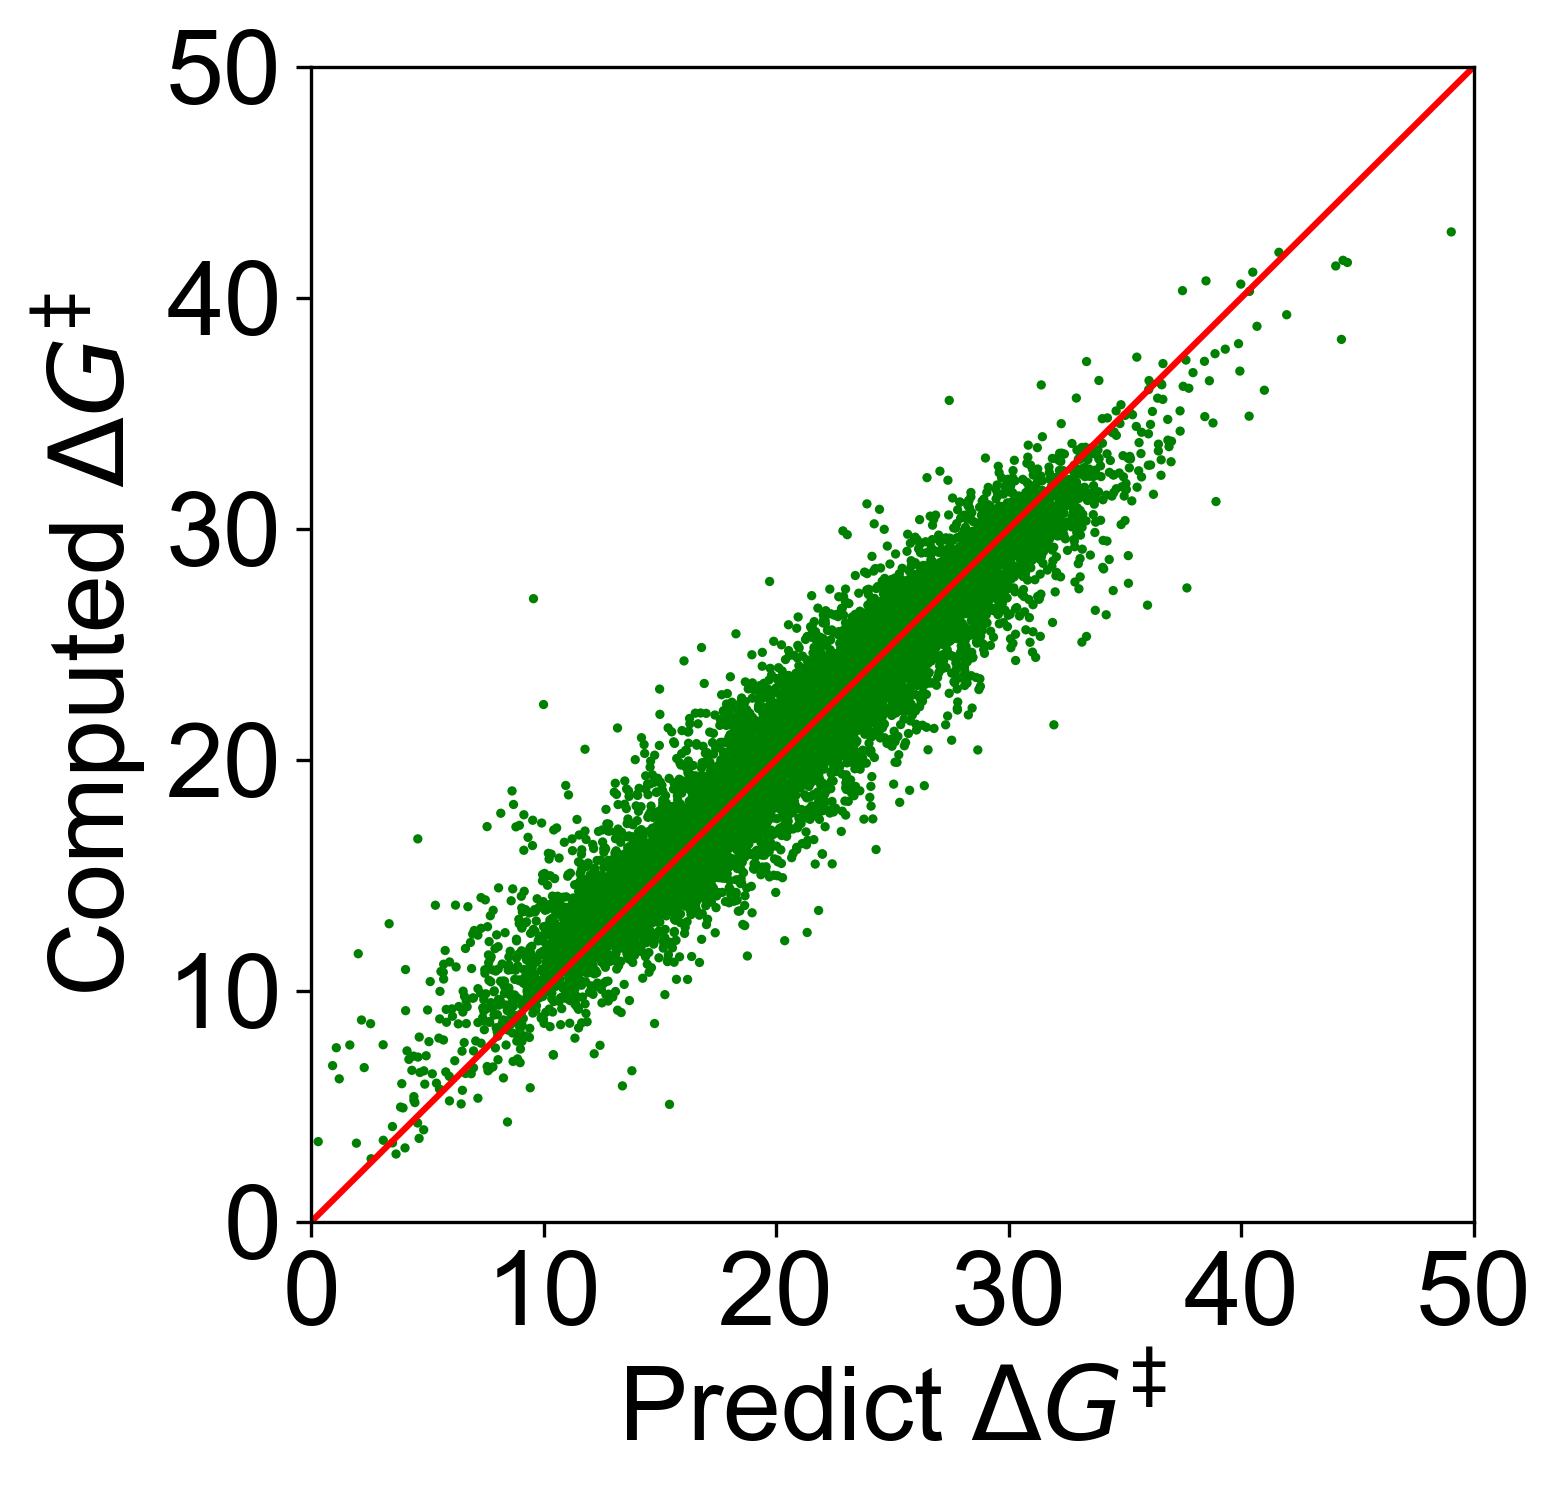

In [12]:
plot_scatter_with_metrics(y, all_pred, min_=0, max_=50)


In [18]:
all_X = np.concatenate([all_Xs, y.reshape(-1, 1)], axis=1)
all_X.shape, np.array(all_Xs).shape

((9236, 19), (9236, 18))

0.8949429795249786


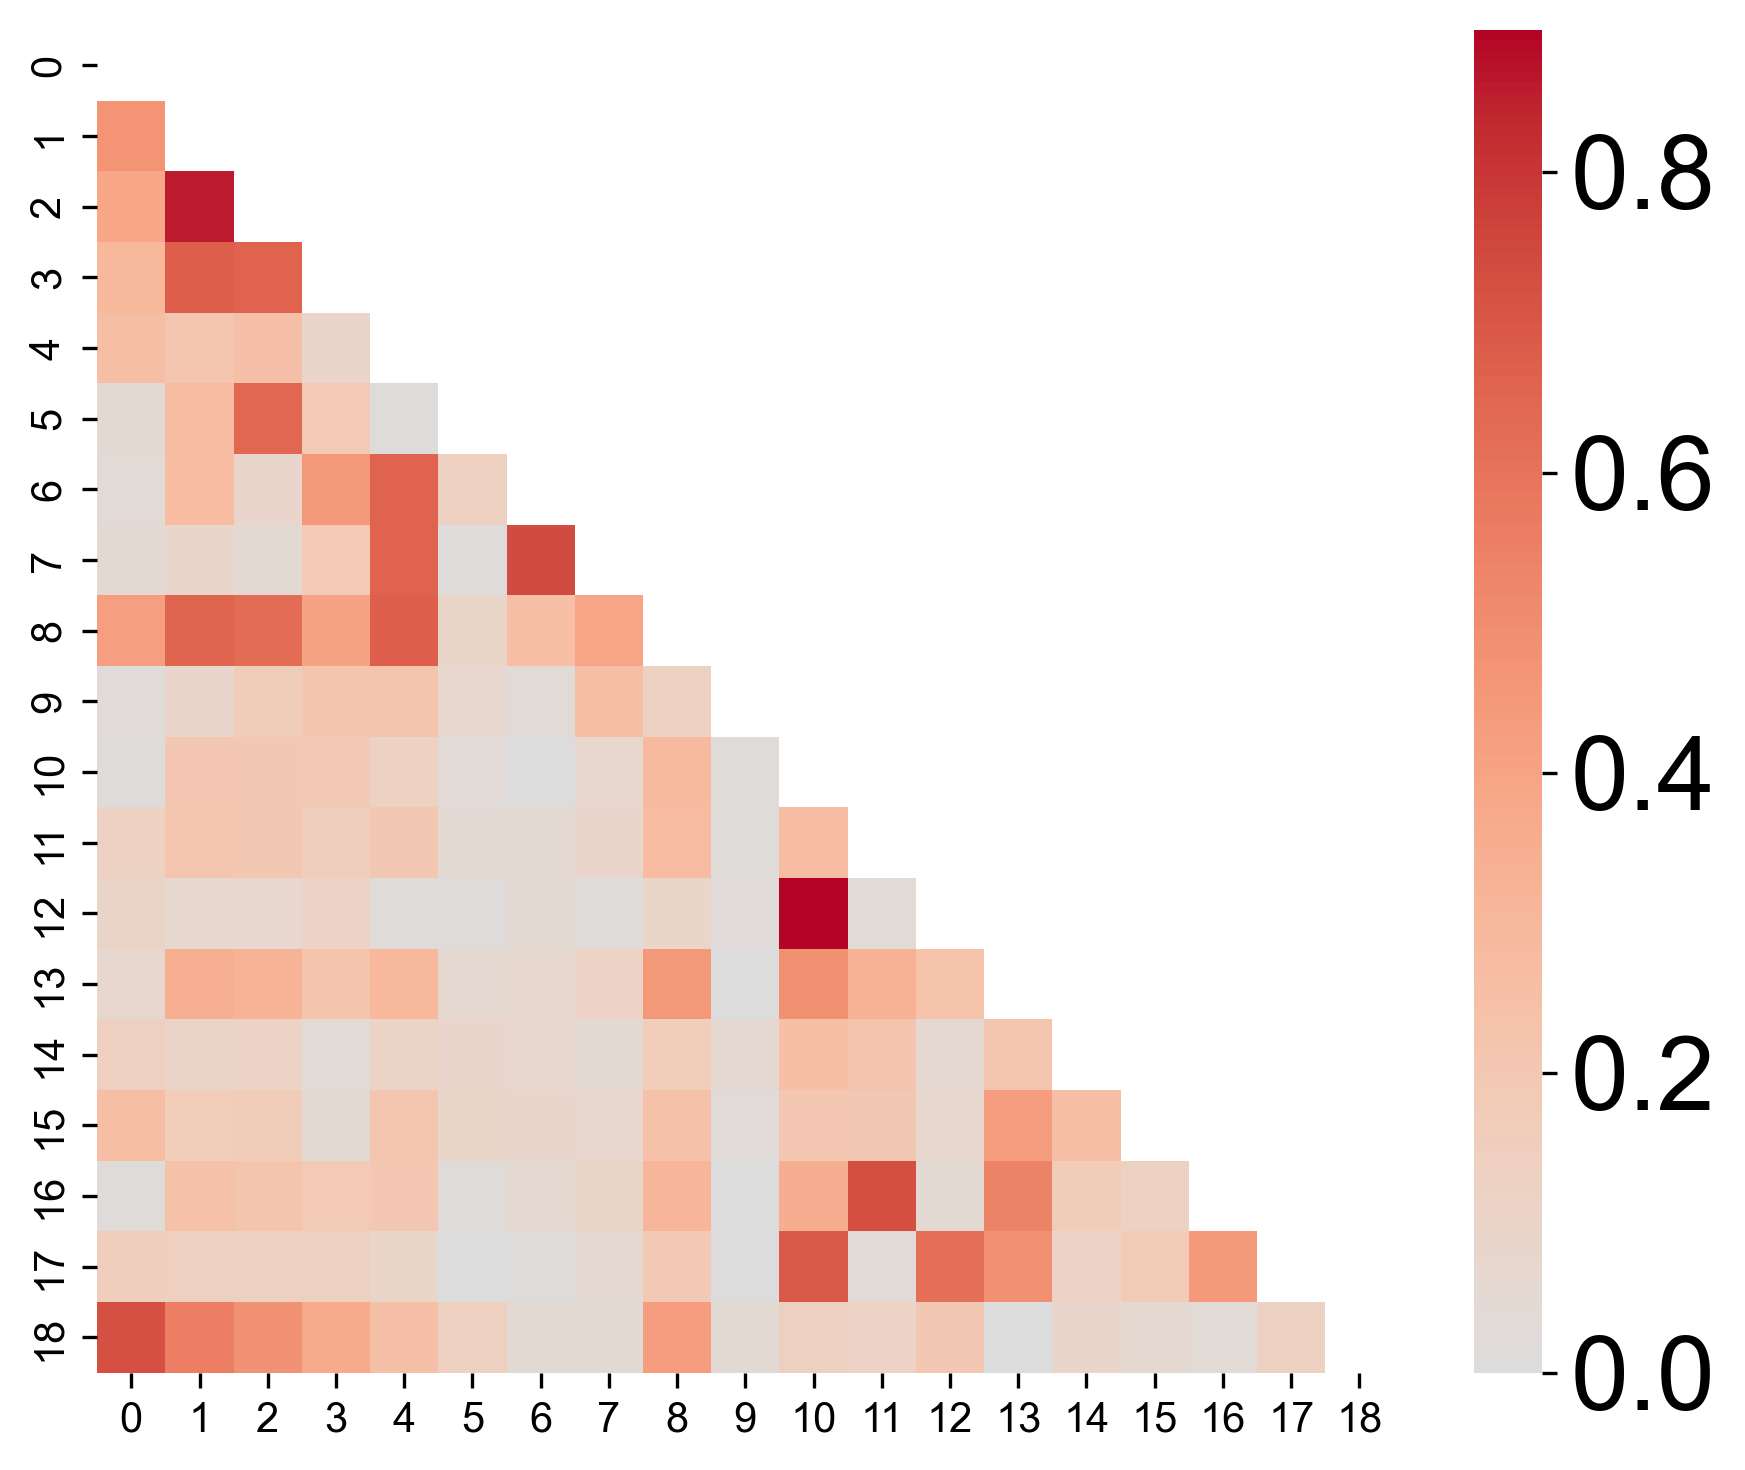

In [21]:
all_X = np.concatenate([all_Xs, y.reshape(-1, 1)], axis=1)
correlation_matrix = draw_correlation_map(all_X, figure_size=(6, 5), colors='coolwarm', annot=False, show_label=True)

In [20]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
model.fit(all_Xs, y)
FI = model.feature_importances_

In [22]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

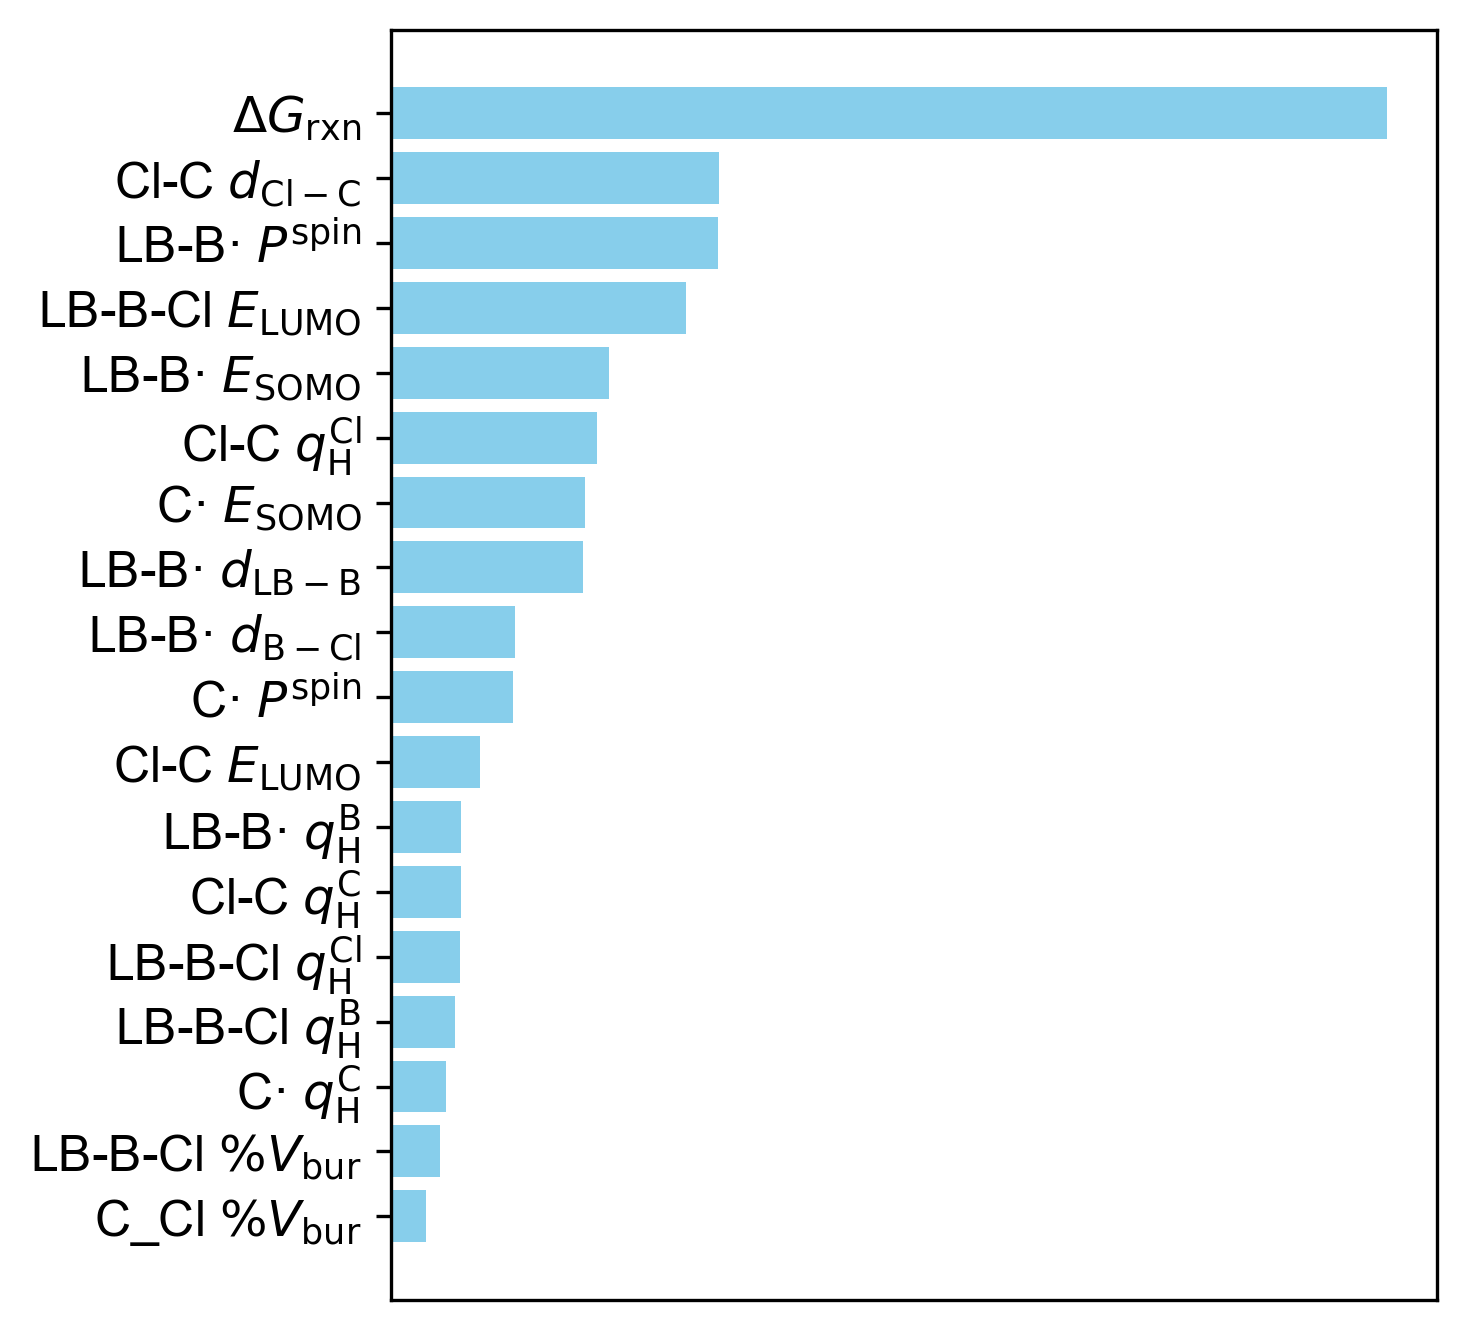

In [23]:
plt.figure(figsize=(4.5,5.5), dpi=300)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.barh(np.array(des_name_std_sorted)[np.argsort(FI)], np.sort(FI), color='skyblue')
# plt.xlabel('Feature Importance')
plt.xticks([])
plt.yticks(fontsize=12)
# plt.ylabel('Features')
# plt.title('Feature Importances')
plt.savefig("Ignored/Feature_Importance.png", dpi=300, bbox_inches='tight')

# OOD

## OOD around chlorine substrates

7237it [00:00, 39595.64it/s]
1999it [00:00, 36204.63it/s]
7496it [00:00, 40004.66it/s]
1740it [00:00, 43013.18it/s]
7567it [00:00, 39814.36it/s]
1669it [00:00, 42132.88it/s]
7409it [00:00, 41477.71it/s]
1827it [00:00, 42301.22it/s]
7235it [00:00, 39712.24it/s]
2001it [00:00, 39936.82it/s]


R2: 0.8109193524922607 MAE: 1.8995295107363668


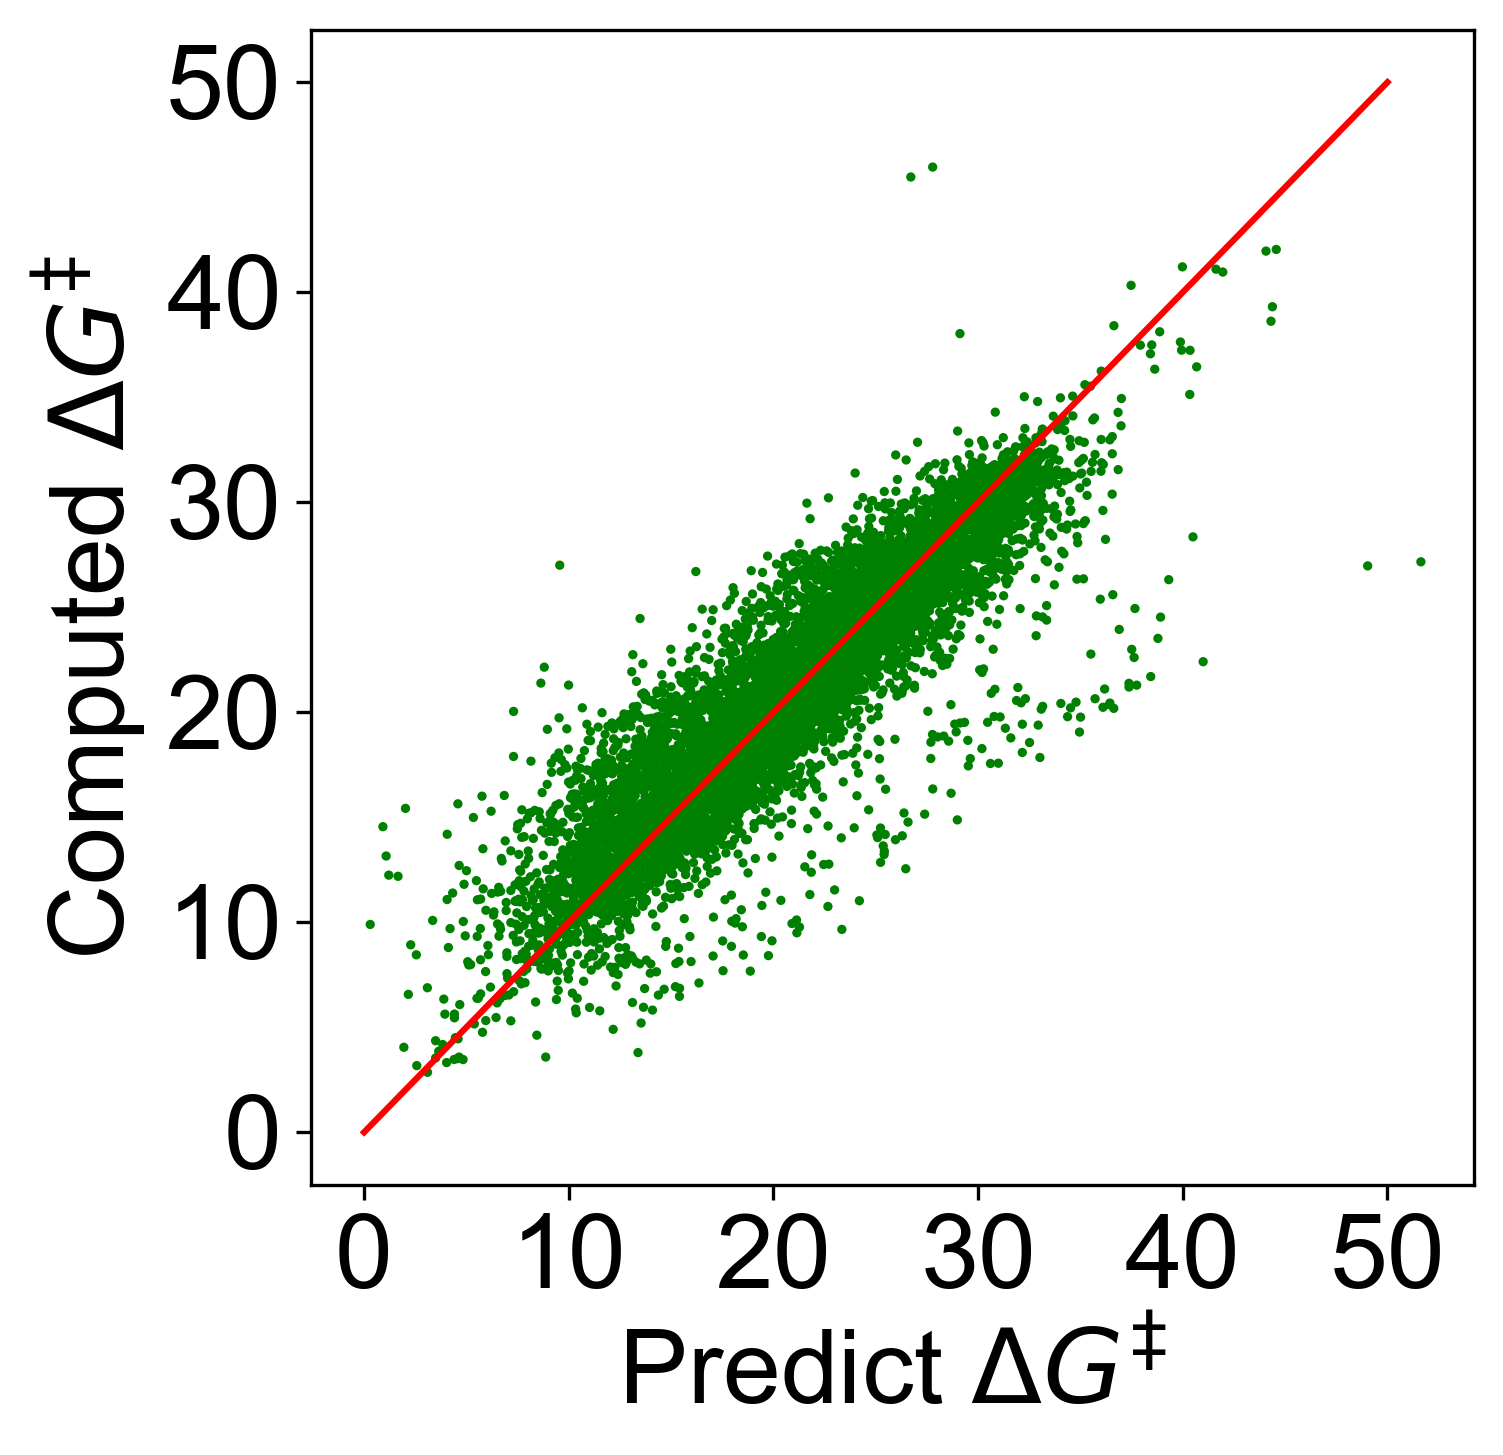

In [51]:
Cl_Indexs = np.sort(data_csv['Cl_Index'].unique())
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s, all_maes = [], []
all_pred = []
all_real = []
for i, (train_index, test_index) in enumerate(kf.split(Cl_Indexs)):
    train_Cl_index = Cl_Indexs[train_index]
    test_Cl_index = Cl_Indexs[test_index]
    train_df = data_csv.loc[data_csv['Cl_Index'].isin(train_Cl_index)].reset_index(drop=True)
    test_df = data_csv.loc[data_csv['Cl_Index'].isin(test_Cl_index)].reset_index(drop=True)
    train_X = dataframe_to_descriptors(train_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    test_X = dataframe_to_descriptors(test_df, B_N_des_map, Cl_des_map, duplicate_cl_ids=duplicate_Cl_id)
    train_y = train_df['deltaGa(kcal/mol)']
    test_y = test_df['deltaGa(kcal/mol)']

    model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
    model.fit(train_X, train_y)
    y_pred = model.predict(test_X)
    all_r2s.append(r2_score(test_y, y_pred))
    all_maes.append(mean_absolute_error(test_y, y_pred))
    all_pred.extend(y_pred)
    all_real.extend(test_y.to_numpy())
print("R2:", np.mean(all_r2s), "MAE:", np.mean(all_maes))
plot_scatter_with_metrics(np.array(all_real), np.array(all_pred), min_=0, max_=50)
